<div style='text-align:center; border:1px solid #cecece; padding:1rem'>
    <h1>Regime de Juros Simples</h1>
    <h3>A Lógica do Rendimento Linear</h3>
</div>

A compreensão dos juros simples vai além da memorização de fórmulas, é necessário entender que o juros é uma compensação econômica baseada em riscos e custos.

Este notebook tem por propósito a aplicação do regime simples com uso de python.


## Autoria
***
Wellington M. Santos - Cientista de Dados  
**LinkedIn**: [in/wellington-moreira-santos](https://linkedin.com/in/wellington-moreira-santos)  
**GitHub**: [/esscova](https://www.github.com/esscova)  
**Email**: [wsantos08@hotmail.com](mailto:wsantos08@hotmail.com)

## Sumário 
***
1. A Natureza dos Juros: Por que o dinheiro custa dinheiro?
2. O Conceito de Juros Simples e Suas Variáveis
3. Estrutura Matemática: As Fórmulas Fundamentais
4. A Regra de Ouro: Consistência de Unidades e Conversão de Taxas
5. Resolução de Problemas: Descobrindo as Variáveis
6. Visualizando a Linearidade: O Gráfico do Juros Simples
7. Exercícios Práticos 

## 1. A Natureza dos Juros: Por que o dinheiro custa dinheiro? 
***
Os juros não são um "mal" da sociedade; são a compensação financeira por ceder o controle do seu capital a terceiros por um tempo. Segundo Victor Menezes, a existência dos juros baseia-se em 4 pilares: 

     Risco: A chance de o dinheiro não voltar (inadimplência).
     Despesas Operacionais: O custo do banco/financiadora existir.
     Inflação: A perda do poder de compra da moeda ao longo do tempo.
     Custo de Oportunidade: O que você deixou de ganhar em outro lugar ao travar seu dinheiro aqui.
     

## 2. O Conceito de Juros Simples e Suas Variáveis 
***
A marca registrada do regime de juros simples é: A taxa incide sempre sobre o Capital Inicial. Não há "juros sobre juros". O rendimento por período é constante. 

| Símbolo | Termo | Definição |
| :--- | :--- | :--- |
| **C** | Capital | Valor inicial (Principal) |
| **i** | Taxa | Percentual aplicado (ex: ao mês, ao ano) |
| **n** | Período | Tempo que o capital fica aplicado |
| **J** | Juros | Remuneração total acumulada |
| **M** | Montante | Soma do Capital + Juros (Valor Futuro) |

## 3. Estrutura Matemática: As Fórmulas Fundamentais 
***
A partir da relação $J=M−C$, chegamos a duas fórmulas essenciais: 

1. **Fórmula dos Juros:** $J=C\cdot i \cdot n $
2. **Fórmula do Montante:** $M=C \cdot (1+i \cdot n)$ 
     
Vamos implementar uma classe em Python que encapsule essa matemática e permita calcular qualquer variável isoladamente. 

In [3]:
class JurosSimples:
    def __init__(self, C=None, i=None, n=None, M=None):
        self.C = C # capital
        self.i = i # taxa decimal ex. 0.03
        self.n = n # periodo
        self.M = M # montante

    def calcular_juros(self):
        """J = C * i * n"""
        if all(v is not None for v in [self.C, self.i, self.n]):
            return self.C * self.i * self.n
        return None

    def calcular_montante_direto(self):
        """M = C * (1 + i * n)"""
        if all(v is not None for v in [self.C, self.i, self.n]):
            return self.C * (1 + self.i * self.n)
        return None

    def encontrar_capital(self):
        """C = M / (1 + i * n)"""
        return self.M / (1 + self.i * self.n)

    def encontrar_taxa(self):
        """i = J/(C*n) -> J = M -C """
        J = self.M - self.C
        return J / (self.C * self.n)

    def encontrar_periodo(self):
        """n = J / (C*i) -> J = M - C"""
        J = self.M - self.C
        return J / (self.C * self.i)

Teste rápido

In [4]:
op = JurosSimples(C=1000, i=0.03, n=5)

print( f'Juros   : R${op.calcular_juros():.2f}' )
print( f'Montante: R${op.calcular_montante_direto():.2f}' )

Juros   : R$150.00
Montante: R$1150.00


## 4. A Regra de Ouro: Consistência de Unidades

O maior erro em matemática financeira é misturar meses com anos. Se a taxa é ao mês (a.m.), o período \(n\) deve ser expresso em meses.

No regime de juros simples, a relação entre tempo e taxa é diretamente proporcional. Isso nos permite estabelecer uma regra prática para conversão de taxas, conhecida como **Equivalência Simples**:

$$
i_2 = i_1 \times \frac{n_2}{n_1}
$$

Onde:
- ($i_1$): taxa original  
- ($i_2$): taxa convertida  
- ($n_1$): unidade de tempo da taxa original  
- ($n_2$): unidade de tempo da taxa desejada  

Por exemplo, para converter uma taxa mensal para anual:

$$
i_{anual} = i_{mensal} \times 12
$$

>Dica: Se o tempo aumenta, a taxa também deve aumentar na mesma proporção.

In [72]:
def converter_taxa_simples(taxa_original: float, unidade_original: str, unidade_destino: str) -> float:
    """
    Converte uma taxa de juros no regime simples entre diferentes unidades de tempo.

    Parâmetros:
    - taxa_original: Taxa de juros original (ex: 1.5 para 1,5%).
    - unidade_original: Unidade de tempo da taxa original (ex: "mensal", "anual", "diaria").
    - unidade_destino: Unidade de tempo desejada para a taxa convertida (ex: "mensal", "anual", "diaria").

    Retorna:
    - Taxa convertida para a unidade de destino.
    """

    # dicionario com os fatores de conversão entre unidades de tempo
    fatores = {
        "diaria": 1,
        "mensal": 30,
        "bimestral": 60,
        "trimestral": 90,
        "semestral": 180,
        "anual": 360,
    }

    # verificar unidades
    if unidade_original not in fatores or unidade_destino not in fatores:
        raise ValueError("Unidade de tempo inválida. Use: 'diaria', 'mensal', 'bimestral', 'trimestral', 'semestral' ou 'anual'.")

    # taxa convertida
    taxa_convertida = taxa_original * (fatores[unidade_destino] / fatores[unidade_original])

    return taxa_convertida

Exemplo: Qual a taxa anual equivalente a 3% ao més no regime simples?

In [73]:
i_mensal = 0.03
i_anual  = converter_taxa_simples(i_mensal, 'mensal', 'anual')

print( f'Taxa mensal: {i_mensal:.2%}' )
print( f'Taxa anual equivalente (simples): {i_anual:.2%}' )

Taxa mensal: 3.00%
Taxa anual equivalente (simples): 36.00%


## 5. Resolução de Problemas: Descobrindo as Variáveis 

Frequentemente, os problemas fornecem três variáveis e pedem a quarta. Vamos usar a nossa classe para resolver os 4 exemplos do texto: 

- Caso 1: Cálculo de Juros e Montante    
    Capital R\$ 1.000,00, taxa 3% a.m., prazo 5 meses. 

- Caso 2: Cálculo do Capital    
    Montante R\$ 2.400,00, prazo 2 meses, taxa 10% a.m. 

- Caso 3: Cálculo do Prazo (n)    
    Capital R\\$ 3.000,00, Montante R$ 3.540,00, taxa 3% a.m. 

- Caso 4: Cálculo da Taxa (i)    
    Capital R\\$ 10.000,00, Juros R$ 5.000,00, prazo 10 meses. 

In [7]:
# caso 1
c1 = JurosSimples(C=1000, i=0.03, n=5)
print('Caso 1')
print(f'Juros: {c1.calcular_juros():.2f}')
print(f'Montante: {c1.calcular_montante_direto():.2f}')

Caso 1
Juros: 150.00
Montante: 1150.00


In [8]:
# caso 2
c2 = JurosSimples(M=2400, i = 0.10, n=2)
print('Caso 2')
print(f'Capital inicial: {c2.encontrar_capital():.2f}')

Caso 2
Capital inicial: 2000.00


In [9]:
# caso 3
c3 = JurosSimples(C=3000, M=3540, i=0.03)
print('Caso 3')
print(f'Prazo(n): {c3.encontrar_periodo():.0f} meses')

Caso 3
Prazo(n): 6 meses


In [10]:
# caso 4
c4 = JurosSimples(C=10_000, M=10_000 + 5000, n=10) # M = C + J
print('Caso 4')
print(f'Taxa (i): {c4.encontrar_taxa():.2%} a.m.')

Caso 4
Taxa (i): 5.00% a.m.


## 6. Visualizando a Linearidade: O Gráfico do Juros Simples 

A melhor forma de entender que "os juros são constantes" é ver o comportamento do Montante ao longo do tempo. No juros simples, a fórmula $M=C \cdot (1+i \cdot n)$ é uma 
função do 1º grau (reta). 

Vamos simular um investimento de R\\$ 1.000 a 5% ao mês por 12 meses e ver como o montante cresce em linha reta. 

In [20]:
import matplotlib.pyplot as plt
import numpy as np

C_inicial = 1000
i_taxa = 0.05
meses = np.arange(0, 13) # 0 a 12 meses

# montante para cada mes :: M = C * (1 + i * n)
montantes = C_inicial * (1 + i_taxa * meses)

# juros acumulados para cada mes :: J = C * i * n
juros_acumulados = C_inicial * i_taxa * meses

In [21]:
meses

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [22]:
montantes

array([1000., 1050., 1100., 1150., 1200., 1250., 1300., 1350., 1400.,
       1450., 1500., 1550., 1600.])

In [23]:
juros_acumulados

array([  0.,  50., 100., 150., 200., 250., 300., 350., 400., 450., 500.,
       550., 600.])

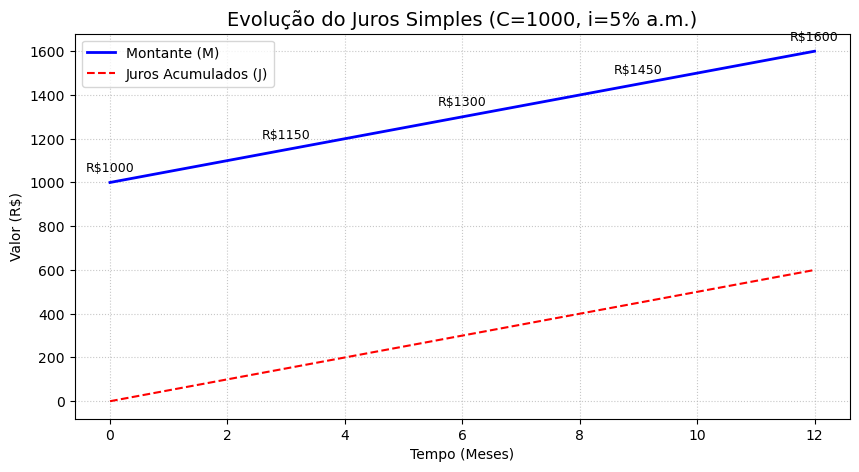

In [36]:
# visualização
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(meses, montantes, label='Montante (M)', color='blue', linewidth=2)
ax.plot(meses, juros_acumulados, label='Juros Acumulados (J)', color='red', linestyle='--')

ax.set_title('Evolução do Juros Simples (C=1000, i=5% a.m.)', fontsize=14)
ax.set_xlabel('Tempo (Meses)')
ax.set_ylabel('Valor (R$)')
ax.legend()
ax.grid(True, linestyle=':', alpha=0.7)

# valores no grafico
for mes, mont in zip(meses, montantes):
    if mes % 3 == 0: # 3 em 3 para não poluir
        ax.text(mes, mont + 50, f"R${mont:.0f}", ha='center', fontsize=9)

plt.show()

## 7. Exercícios Práticos

### 7.1. Desafio 1
Um capital de R\\$ 5.000,00 é aplicado a uma taxa de juros simples de 8% ao trimestre. Qual será o montante após 1 ano e 6 meses? (Dica: Cuidado com a consistência de unidades!)

In [45]:
C = 5000
i = 0.08 
n = 6

print(f'Montante R$: {JurosSimples(C, i, n).calcular_montante_direto():.2f}')

Montante R$: 7400.00


### 7.2. Desafio 2
Quanto tempo (em meses) um capital de R\\$ 15.000,00 deve ser aplicado a uma taxa de 2% ao mês para gerar R\\$ 7.500,00 de juros?

In [50]:
J = 7500
C = 15_000
i = 0.02

print(f'Período: {JurosSimples(M=J+C, C=C, i=i).encontrar_periodo():.0f} meses')

Período: 25 meses


### 7.3. Desafio 3
Usando a função converter_taxa_simples, descubra qual a taxa anual equivalente a 1,5% ao mês no regime simples.

In [75]:
i_mensal = 0.015
i_anual = converter_taxa_simples(i_mensal, 'mensal', 'anual')

print(f"Taxa Anual Equivalente (Simples): {i_anual:.2%}") 

Taxa Anual Equivalente (Simples): 18.00%
